## I. Problem identification and motivation
In many engineering applications, mathematical models are developed from measured data to predict system behavior and support engineering decisions. In this project, building energy consumption is modeled as a function of occupancy using a polynomial approximation. Although a high-degree polynomial can provide a flexible model for nonlinear behavior, representing the polynomial with the monomial (Vandermonde) basis can create severe numerical difficulties. As the polynomial order increases, the columns of the Vandermonde matrix become highly correlated, making the associated optimization problem ill-conditioned. This can produce very small eigenvalues in the Hessian matrix, a large condition number, slow gradient-based convergence, and increased sensitivity to rounding errors.The motivation of this project is therefore to obtain an accurate polynomial model while improving the numerical stability of the optimization process. To achieve this, the project replaces the highly correlated monomial basis with a more nearly orthogonal Chebyshev basis. The normalized input domain of $[-1, 1]$ is well suited to Chebyshev polynomials and helps reduce scale-related numerical effects. By reducing correlation between basis functions, the Chebyshev formulation improves the conditioning of the problem and allows the optimization algorithm to converge much more efficiently. In the presented experiment, the monomial formulation required more than $10{,}000$ iterations, whereas the Chebyshev formulation converged in $54$ iterations. Thus, the project demonstrates that an appropriate choice of polynomial basis can significantly improve the reliability and computational efficiency of engineering data modeling.
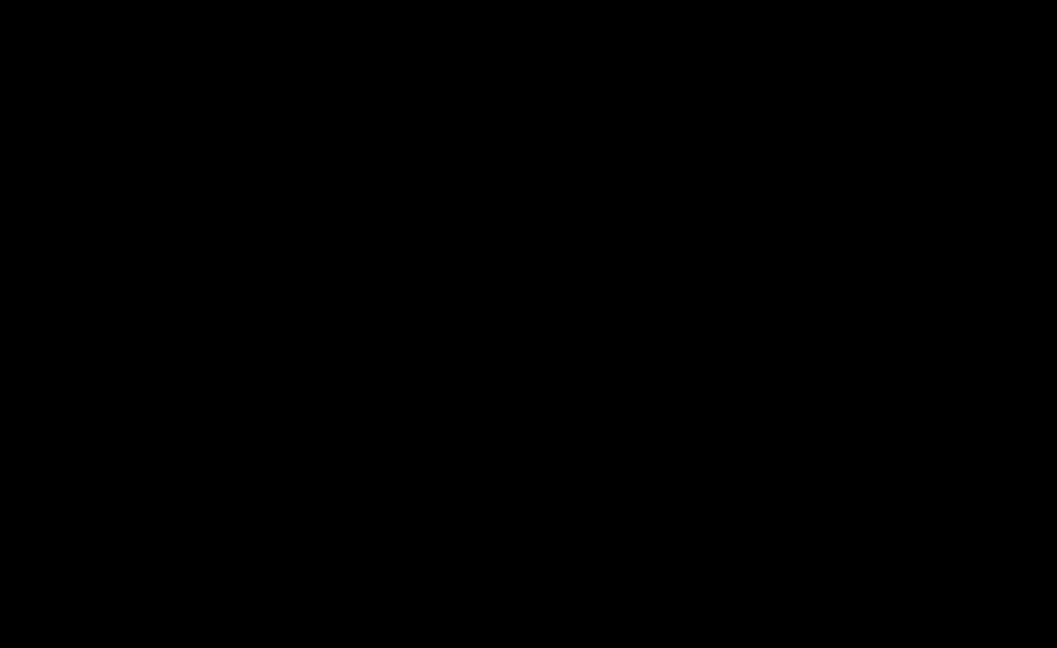
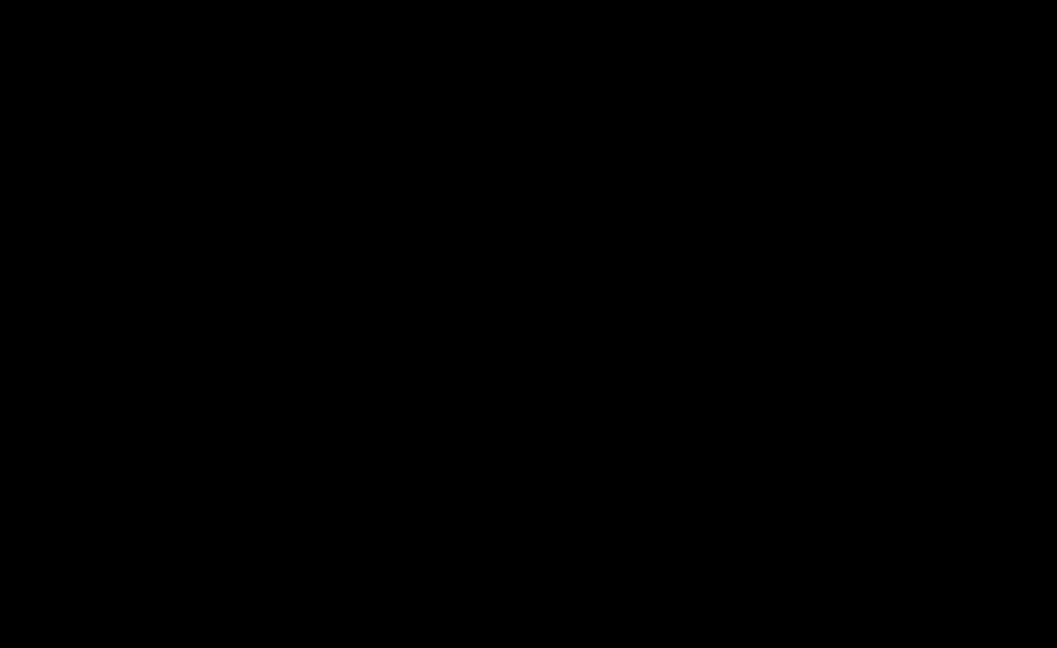
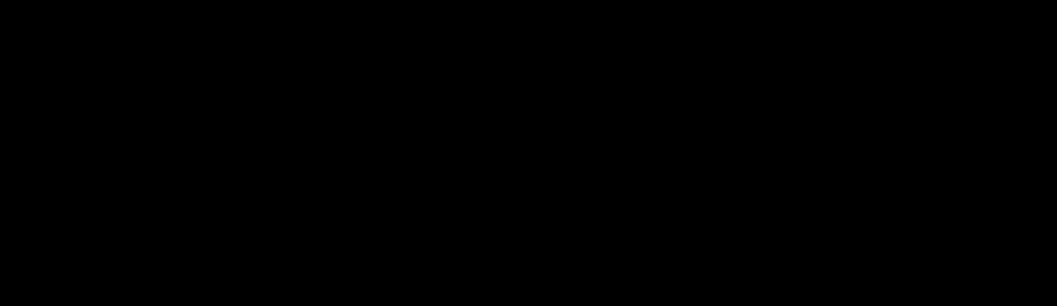

## II. Formulation
### A. Design Variable
The design variable for this problem is the coefficients for the polynomial model.
$$
\ \mathbf{a} = [a_0, ...., a_{n-1}]
$$
Where the coefficients must be a real number
$$\ a_i \in \mathbb{R} $$
$$ i = 1, ...,n-1$$
Where each element of the vector $\mathbf{a}$ is a continuous variable

### B. Objective Function
The method to get the objective function is the use of the least squares residual method. The residual vector is:
$$
\mathbf{r} =
V\mathbf{a}-\mathbf{y}.
$$
Converting it into the least-squares objective function:
$$
\boxed{
\operatorname{min}
f(\mathbf{a}) =
\frac{1}{2}
\left\|
V\mathbf{a}-\mathbf{y}
\right\|_2^2.}
$$
The $V$ is the Vandermonde matrix. Finding the Hessian of the objective function:
$$
\nabla f(\mathbf{a}) = V^T(V\mathbf{a}-\mathbf{y})
$$
$$
H=V^TV.
$$

### C. Problem Classification
This problem is a quadratic programming because the objective function is the quadratic with respect to the design variable $\mathbf{a}$. Generally the problem is a convex problem, however because of ill-conditioning at higher order polynomial the problem seems like a non-convex problem. The higher order polynomial not only creates a high condition number, but also creates a problem for the digital computation system where data are lost due to rounding errors.

### D. Normalization
Before constructing the polynomial basis, the occupancy data is
normalized to the interval $[-1,1]$ using min-max normalization:

$$
x_{\mathrm{norm}}
=
2\left(
\frac{x_{raw}-x_{\min}}
{x_{\max}-x_{\min}}
\right)-1.
$$
This transformation maps the minimum training value to $-1$ and the
maximum training value to $1$. Normalization is used to improve the numerical behavior of the
polynomial model and to place the input data on the natural interval of
the Chebyshev basis. Chebyshev polynomials are defined and have their
useful orthogonality properties on $[-1,1]$. Keeping the input within
this interval also prevents high-degree polynomial terms from becoming
unnecessarily large.

Also an important aspect of the equation is the values $x_{\min}$ and $x_{\max}$ are calculated from the training
data and the same transformation is then applied to the test data.

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from sklearn.model_selection import train_test_split

# ============================================================
# 1. Load and Preprocess External Data
# ============================================================

# Read CSV file (adjust filename/path if needed)
df = pd.read_csv('test_energy_data.csv')

df = df[df['Building Type'] == 'Residential']

# Extract Occupancy (x) and Energy Used (y) FIRST
x_raw = df['Number of Occupants'].values
y = df['Energy Consumption'].values

# Split the data into Training and Test sets (e.g., 70% train, 30% test)
x_train, x_test, y_train, y_test = train_test_split(
    x_raw,
    y,
    test_size=0.3,
    random_state=42
)

# Sort the training values by x for clean plotting lines later
sort_idx = np.argsort(x_train)
x_train = x_train[sort_idx]
y_train = y_train[sort_idx]

# CRITICAL STEP: Min-Max normalize x to [-1, 1]
# Note: When splitting data, you should calculate the min and max
# strictly from the training set to prevent data leakage.
x_min, x_max = x_train.min(), x_train.max()
x_train_norm = 2.0 * (x_train - x_min) / (x_max - x_min) - 1.0
x_test_norm = 2.0 * (x_test - x_min) / (x_max - x_min) - 1.0

# ============================================================
# 2. Gradient Descent Solver (from p2_testfile.py)
# ============================================================

def gradient_descent(V, y, max_iter=10000, tol=1e-12):
    H = V.T @ V
    eigenvalues = np.linalg.eigvalsh(H)
    lambda_max = eigenvalues[-1]
    alpha = 1.0 / lambda_max

    a = np.zeros(V.shape[1])
    a_star, _, _, _ = np.linalg.lstsq(V, y, rcond=None)

    residual_star = V @ a_star - y
    f_star = 0.5 * np.dot(residual_star, residual_star)

    residual_0 = V @ a - y
    f_0 = 0.5 * np.dot(residual_0, residual_0)

    normalized_gaps = []
    for k in range(max_iter):
        residual = V @ a - y
        loss = 0.5 * np.dot(residual, residual)
        normalized_gap = (loss - f_star) / (f_0 - f_star)
        normalized_gap = max(normalized_gap, 1e-16)
        normalized_gaps.append(normalized_gap)

        if normalized_gap < tol:
            break

        gradient = V.T @ residual
        a = a - alpha * gradient

    return a, normalized_gaps

## III. Ill-Conditioning Mechanism
### A. Large Kappa Argument
The problem belongs to Family-C. The problem becomes ill-conditioned as the order of polynomial increases. For a standard monomial basis $[1,x,x^2,...,x^d]$, $x^8$ and $x^9$ would produce a very small value when $x=[0,1]$ (only steeply increase to 1 when $x \approx 1$). This makes $x^8$ and $x^9$ nearly identical. Since the Vandermonde matrix is:
$$
V_{\mathrm{mono}}
=
\begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d\\
1 & x_2 & x_2^2 & \cdots & x_2^d\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_n & x_n^2 & \cdots & x_n^d
\end{bmatrix}.
$$
The columns with the higher order x-terms would be approximately zero, creating redundancy columns. Using the equation of Hessian:
$$
H=V^TV.
$$
the Hessian matrix would inhere the redundant columns. This results in an eigenvalue that is near zero for the smallest eigenvalue. since the condition number is represented by equation:
$$
\kappa = \lambda_{max}/\lambda_{min}
$$
the condition number is a very large value as result. One more problem that rises from this is for a standard 64-bit floating point number, the computer only stores a fixed number of decimal points. Once the actual number is smaller than what can be stored, the computation result is serverly effected due to rounding errors.

### B. Test Diagonal Rescaling
Large kappa value may also arises due to different scaling factors from the data set. For a higher order x-value terms in the Vandermond matrix, typically the column would be a very small value (unless it is near 1 then it is approximately 1), much smaller than the lower order x-value terms. The equation of the Hessian is defined above, so if focused on just the diagonal term of the Hessian, the equation is:
$$
H_{ii} = v_i^Tv_i = ||v_i||_2^2
$$
Note that $v_i$ is the $i^{th}$ column of the Vandermonde matrix. This equation would result is two extremes, either there is a large term or a very small term. This results in the creation of large eigenvalue and very small eigenvalue. In order to find out if rescaling is an issue with the Vandermonde matrix, Jacobi-scaling method is applied.
$$
\tilde{H} = D^{-1/2}HD^{-1/2}
$$
$$
D = diag(H)
$$
This equation gives an alternate Hessian matrix where the diagonal elements are 1. For the off diagonal terms, the eqaution becomes that of a cosine:
$$
\tilde{H}_{ij} = \frac{<v_i,v_j>}{||v_i||_2 ||v_j||_2} = \cos{\theta_{ij}}
$$
where $\theta_{ij}$ is the angle between each column the two columns. Also, the nnumerator term $<v_i,v_j>$ is the inner product (dot product) between two columns. If the underlying columns of the Vandermonde matrix are orthagonal to each other, this results in $\theta_{ij}=\pi/2$ which results in $\tilde{H} = I$. This results in kappa being equal to 1, which is trivial. The other case, if the columns are nearly similar to each other, like it is at higher order elements in Vandermonde matrix, the dot product would result in 1 therefore creating a larger condition number.

## C. D2 Graph Interpretation
From the kappa vs. polynomial degrees graph below, there is a small difference between the rescaled kappa value and non-rescaled kappa value for both the monomial and Chebyshev basis. This result justifies that the ill-condition doesn't come from poor scaling factor in the Vandermonde matrix, but there is a deeper reason to it.

Degree   | Monomial Kappa     | Monomial Kappa (Rescaled)   | Chebyshev Kappa    | Chebyshev Kappa (Rescaled) 
----------------------------------------------------------------------------------------------------
2        | 1.385e+01          | 8.954e+00                   | 2.707e+00          | 1.787e+00                  
4        | 4.702e+02          | 2.319e+02                   | 5.080e+00          | 3.507e+00                  
6        | 1.197e+04          | 5.924e+03                   | 5.961e+00          | 4.626e+00                  
8        | 4.170e+05          | 2.251e+05                   | 8.861e+00          | 6.844e+00                  
10       | 2.013e+07          | 1.194e+07                   | 1.177e+01          | 9.428e+00                  
12       | 7.396e+08          | 4.753e+08                   | 5.555e+01          | 4.504e+01                  
14       | 9.417e+10          | 6.389e+10                   | 4.570e+02          | 3.716e+02                  


<Figure size 640x480 with 0 Axes>

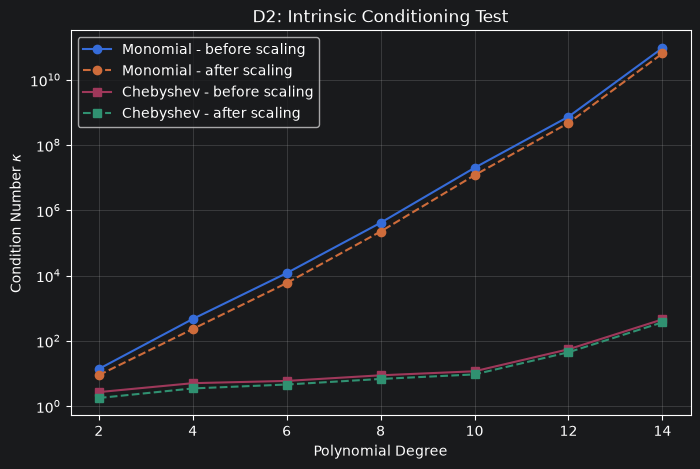

In [223]:
# ============================================================
# 3. Conditioning Diagnostics Across Degrees (kappa comparison)
# ============================================================
def jacobi_rescaled_hessian(H):
    d = np.diag(H)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
    return D_inv_sqrt @ H @ D_inv_sqrt

degrees = [2, 4, 6, 8, 10, 12, 14]
# Place holder
mono_kappas = []
cheb_kappas = []
mono_kappas_scaled = []
cheb_kappas_scaled = []

mono_raw = []
mono_scaled = []
cheb_raw = []
cheb_scaled = []

print(f"{'Degree':<8} | {'Monomial Kappa':<18} | {'Monomial Kappa (Rescaled)':<27} | {'Chebyshev Kappa':<18} | {'Chebyshev Kappa (Rescaled)':<27}")
print("-" * 100)


# D-2 Data Table
for d in degrees:
    # Build Monomial Vandermonde matrix V
    V_mono = np.vander(x_train_norm, N=d + 1, increasing=True)
    H_mono = V_mono.T @ V_mono
    kappa_mono = np.linalg.cond(H_mono)
    # Rescaled Part of Monomial
    H_mono_scaled = jacobi_rescaled_hessian(H_mono)
    kappa_mono_scaled = np.linalg.cond(H_mono_scaled)
    mono_raw.append(np.linalg.cond(H_mono))
    mono_scaled.append(np.linalg.cond(H_mono_scaled))

    # Build Chebyshev Vandermonde matrix
    V_cheb = chebvander(x_train_norm, d)
    H_cheb = V_cheb.T @ V_cheb
    kappa_cheb = np.linalg.cond(H_cheb)
    # Rescaled Part of Chebyshev
    H_cheb_scaled = jacobi_rescaled_hessian(H_cheb)
    kappa_cheb_scaled = np.linalg.cond(H_cheb_scaled)
    cheb_raw.append(np.linalg.cond(H_cheb))
    cheb_scaled.append(np.linalg.cond(H_cheb_scaled))

    # Add the computed Kappa to the end of the list of the blank vectors in the front
    mono_kappas.append(kappa_mono)
    cheb_kappas.append(kappa_cheb)
    mono_kappas_scaled.append(kappa_mono_scaled)
    cheb_kappas_scaled.append(kappa_cheb_scaled)

    print(f"{d:<8d} | {kappa_mono:<18.3e} | {kappa_mono_scaled:<27.3e} | {kappa_cheb:<18.3e} | {kappa_cheb_scaled:<27.3e}")

# Plot required D2 comparison
plt.figure(1)
plt.figure(figsize=(8, 5))

plt.semilogy(
    degrees,
    mono_raw,
    'o-',
    label='Monomial - before scaling'
)

plt.semilogy(
    degrees,
    mono_scaled,
    'o--',
    label='Monomial - after scaling'
)

plt.semilogy(
    degrees,
    cheb_raw,
    's-',
    label='Chebyshev - before scaling'
)

plt.semilogy(
    degrees,
    cheb_scaled,
    's--',
    label='Chebyshev - after scaling'
)

plt.xlabel('Polynomial Degree')
plt.ylabel(r'Condition Number $\kappa$')
plt.title('D2: Intrinsic Conditioning Test')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

## IV. Effect of Ill-Conditioning
From D2 plot in the previous section, the Chebyshev method clearly results in much smaller kappa value than the monomial basis. If plotting their respective eigenvalue, the reason for it can be seen easily. The eigenvalue vs. eigenvalue indices plot below plots the eigenvalue of the Hessian from monomial and Chebyshev methods. It shows that there is a large range between the smallest and the biggest eigenvalue for the monomial basis. From the kappa value equation, this would indicate a large kappa value ($\kappa = 11970$). As for the Chebyshev method, the small difference provides small kappa value ($\kappa = 5.961$).

When $\kappa(H)$ is very large, the objective has very different
curvature in different directions. Large eigenvalues correspond to steep
directions, while very small eigenvalues correspond to relatively flat
directions. For the monomial basis, this creates a long, narrow optimization
landscape. Gradient descent can reduce the error rapidly in steep
directions but makes much slower progress along flat directions.With the Chebyshev basis, the Hessian eigenvalues are more tightly clustered. The condition number is therefore much smaller, producing a
better-conditioned optimization landscape and faster convergence. Looking at the other graph, it shows the amount of iterations it takes for the monomial and Chebyshev method to converge to a solution. It shows that after couple of iterations, the monomial basis stalls in its improvements, even after 10000 iterations the monomial method never gets below the threshold indicating the solution is reached. But the Chebyshev method only requires 64 iterations to reach that point.

Monomial kappa = 1.197434e+04
Chebyshev kappa = 5.960615e+00


<Figure size 640x480 with 0 Axes>

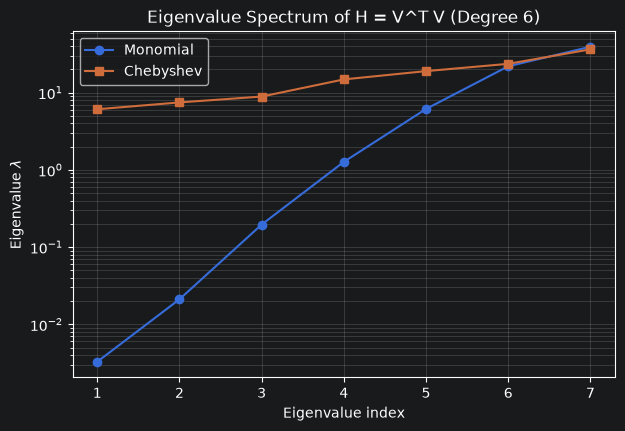

Monomial GD converged in 10000 iterations.
Chebyshev GD converged in 64 iterations.


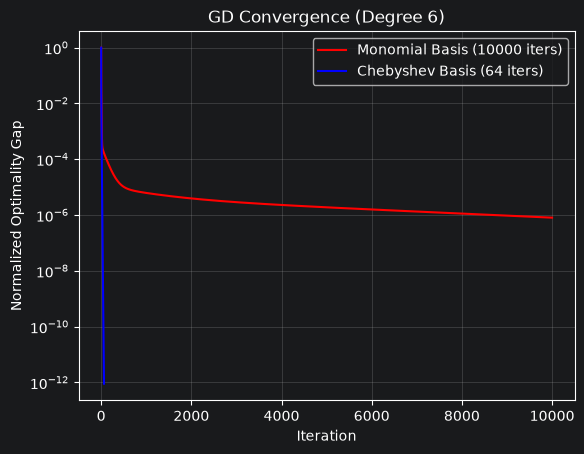

In [224]:
# ============================================================
# IV. Effect of Ill-condition
# ============================================================
target_degree = 6
# Construct design matrices for Training set
V_mono_train = np.vander(x_train_norm, N=target_degree + 1, increasing=True)
V_cheb_train = chebvander(x_train_norm, target_degree)

# Construct design matrices for Testing set
V_mono_test = np.vander(x_test_norm, N=target_degree + 1, increasing=True)
V_cheb_test = chebvander(x_test_norm, target_degree)

# Optimal least-squares coefficients computed ON THE TRAINING SET ONLY
a_mono_star, _, _, _ = np.linalg.lstsq(V_mono_train, y_train, rcond=None)
a_cheb_star, _, _, _ = np.linalg.lstsq(V_cheb_train, y_train, rcond=None)

# Predictions on Training Set
y_pred_mono_train = V_mono_train @ a_mono_star
y_pred_cheb_train = V_cheb_train @ a_cheb_star

# Predictions on Testing Set
y_pred_mono_test = V_mono_test @ a_mono_star
y_pred_cheb_test = V_cheb_test @ a_cheb_star

# Gradient Descent convergence test on training set (Required for Plot 3)
a_gd_mono, gaps_mono = gradient_descent(V_mono_train, y_train, max_iter=10000)
a_gd_cheb, gaps_cheb = gradient_descent(V_cheb_train, y_train, max_iter=10000)

# ============================================================
# Visualization
# ============================================================

# Design matrices on normalized training set
V_mono = np.vander(x_train_norm, N=target_degree + 1, increasing=True)
V_cheb = chebvander(x_train_norm, target_degree)

# Compute Hessians (H = V^T V)
H_mono = V_mono.T @ V_mono
H_cheb = V_cheb.T @ V_cheb

# Sorts in asending order for eigenvalue
eig_mono = np.linalg.eigvalsh(H_mono)
eig_cheb = np.linalg.eigvalsh(H_cheb)

#The largest eigenvalue is counting from other end, the first element.
# The smallest eigenvalue is 0th element or in python, the first.
kappa_mono = eig_mono[-1] / eig_mono[0]
kappa_cheb = eig_cheb[-1] / eig_cheb[0]

# D1 required Kappa Values
print(f"Monomial kappa = {kappa_mono:.6e}")
print(f"Chebyshev kappa = {kappa_cheb:.6e}")

# D1 Plot
plt.figure(2)
plt.figure(figsize=(7, 4.5))
plt.semilogy(range(1, len(eig_mono) + 1), eig_mono,
             'o-', label='Monomial')
plt.semilogy(range(1, len(eig_cheb) + 1), eig_cheb,
             's-', label='Chebyshev')

plt.xlabel('Eigenvalue index')
plt.ylabel(r'Eigenvalue $\lambda$')
plt.title(f'Eigenvalue Spectrum of H = V^T V (Degree {target_degree})')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

# D3 Plot
plt.figure(3)
plt.plot(gaps_mono, color='red', label=f'Monomial Basis ({len(gaps_mono)} iters)')
plt.plot(gaps_cheb, color='blue', label=f'Chebyshev Basis ({len(gaps_cheb)} iters)')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Normalized Optimality Gap')
plt.title(f'GD Convergence (Degree {target_degree})')
plt.legend()
plt.grid(True, alpha=0.3)

# Print the iteration counts for convergence
print(f"Monomial GD converged in {len(gaps_mono)} iterations.")
print(f"Chebyshev GD converged in {len(gaps_cheb)} iterations.")

## V. Proposed Solution and Demonstration
Monomial basis presents a high condition number that results in ill-conditioning effects, this makes the problem non-convex resulting in no clear optimial solution. Using the Chebyshev's orthogonal basis is a remedy to the problem because the base coordinate system of the polynomial is changed. Chebyshev's polynomial is defined by:
$$ T_n(x) = \cos(n \arccos(x))$$
where,
$$ x = \cos(\theta)$$
so the equation becomes:
$$
\boxed{
T_n(x) = \cos(n \theta)}
$$
where $n$ is the order of the basis that is to be converted. A useful trig identity can be used to calculate $T_n(x)$ for higher $n$ values:
$$
T_{n+1}(x) = 2xT_n(x) - T_{n-1}(x)
$$
Apply the above, the first 3 order basis are:
$$
T_0(x)=1,
$$
$$
T_1(x)=x,
$$
$$
T_2(x)=2x^2-1,
$$
$$
T_3(x)=4x^3-3x.
$$
Note that the normalized interval $[-1,1]$, these functions oscillate
differently rather than behaving like increasingly high powers of $x$.
This gives the columns of the Chebyshev design matrix better separation
than the columns of the monomial Vandermonde matrix. These basis can be placed in a Vondermonde matrix, creating:
$$
V_{\mathrm{cheb}}
=
\begin{bmatrix}
T_0(x_1) & T_1(x_1) & \cdots & T_d(x_1)\\
T_0(x_2) & T_1(x_2) & \cdots & T_d(x_2)\\
\vdots & \vdots & \ddots & \vdots\\
T_0(x_n) & T_1(x_n) & \cdots & T_d(x_n)
\end{bmatrix}.
$$
Chebyshev polynomials have the weighted orthogonality property
$$
\int_{-1}^{1}
\frac{T_m(x)T_n(x)}
{\sqrt{1-x^2}}\,dx=0,
\qquad m\neq n.
$$
Thus, under their natural weighted inner product, different Chebyshev
basis functions are orthogonal.

The discrete data in this optimization problem does not make the columns
perfectly orthogonal, but this property helps explain why the Chebyshev
columns can be substantially less correlated than monomial columns.

The least-squares Hessian is

$$
H=V^TV.
$$

Its entries are inner products between columns of $V$:

$$
H_{ij}=v_i^Tv_j.
$$

If the columns were perfectly orthogonal, then

$$
v_i^Tv_j=0,\qquad i\neq j,
$$

and $V^TV$ would be diagonal.

Therefore, reducing correlation between the basis functions improves the
structure of the Hessian. In the Chebyshev formulation, the Hessian
eigenvalues are more tightly clustered than in the monomial formulation,
giving

$$
\kappa(H_{\mathrm{cheb}})
\ll
\kappa(H_{\mathrm{mono}}).
$$


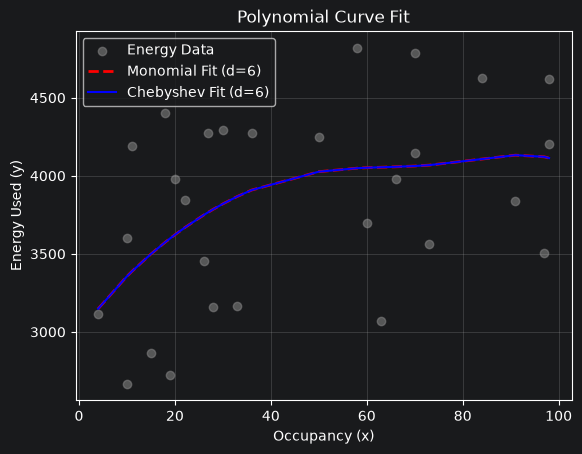

In [225]:
# ============================================================
# 4. Polynomial Fitting & Comparison at Target Degree
# ============================================================

# target_degree = 3
#
# # Construct design matrices using ONLY the normalized training set
# V_mono_train = np.vander(x_train_norm, N=target_degree + 1, increasing=True)
# V_cheb_train = chebvander(x_train_norm, target_degree)
#
# # Compute optimal least-squares coefficients on the training set
# a_mono_star, _, _, _ = np.linalg.lstsq(V_mono_train, y_train, rcond=None)
# a_cheb_star, _, _, _ = np.linalg.lstsq(V_cheb_train, y_train, rcond=None)
#
# # Compute predictions strictly for the training dataset
# y_pred_mono = V_mono_train @ a_mono_star
# y_pred_cheb = V_cheb_train @ a_cheb_star
#
# # Gradient Descent convergence test on training set
# a_gd_mono, gaps_mono = gradient_descent(V_mono_train, y_train, max_iter=10000)
# a_gd_cheb, gaps_cheb = gradient_descent(V_cheb_train, y_train, max_iter=10000)

# Model Fit vs Raw Data
plt.figure(4)
plt.scatter(x_train, y_train, color='gray', alpha=0.6, label='Energy Data')
plt.plot(x_train, y_pred_mono_train, 'r--', linewidth=2, label=f'Monomial Fit (d={target_degree})')
plt.plot(x_train, y_pred_cheb_train, 'b-', linewidth=1.5, label=f'Chebyshev Fit (d={target_degree})')
plt.xlabel('Occupancy (x)')
plt.ylabel('Energy Used (y)')
plt.title('Polynomial Curve Fit')
plt.legend()
plt.grid(True, alpha=0.3)

In [227]:
# ============================================================
# Performance Evaluation & Comparison Table (Train vs Test)
# ============================================================

def compute_metrics(y_true, y_pred):
    # Absolute residual vector
    residual = y_pred - y_true

    # Least-squares objective loss: f(a) = 0.5 * ||r||^2_2
    loss = 0.5 * np.dot(residual, residual)

    # Max absolute residual
    max_abs_res = np.max(np.abs(residual))

    # Coefficient of Determination (R^2)
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot)

    return loss, max_abs_res, r2

# Compute metrics for Monomial basis
loss_mono_tr, max_res_mono_tr, r2_mono_tr = compute_metrics(y_train, y_pred_mono_train)
loss_mono_te, max_res_mono_te, r2_mono_te = compute_metrics(y_test, y_pred_mono_test)

# Compute metrics for Chebyshev basis
loss_cheb_tr, max_res_cheb_tr, r2_cheb_tr = compute_metrics(y_train, y_pred_cheb_train)
loss_cheb_te, max_res_cheb_te, r2_cheb_te = compute_metrics(y_test, y_pred_cheb_test)

# Display tabular comparison
print(f"{'Metric':<32} | {'Monomial (Train)':<16} | {'Monomial (Test)':<16} | {'Chebyshev (Train)':<16} | {'Chebyshev (Test)':<16}")
print("-" * 110)
print(f"{'R^2 (Coefficient of Det.)':<32} | {r2_mono_tr:<16.6f} | {r2_mono_te:<16.6f} | {r2_cheb_tr:<16.6f} | {r2_cheb_te:<16.6f}")
print(f"{'Objective Loss f(a)':<32} | {loss_mono_tr:<16.4f} | {loss_mono_te:<16.4f} | {loss_cheb_tr:<16.4f} | {loss_cheb_te:<16.4f}")
print(f"{'Max Absolute Residual':<32} | {max_res_mono_tr:<16.4f} | {max_res_mono_te:<16.4f} | {max_res_cheb_tr:<16.4f} | {max_res_cheb_te:<16.4f}")

Metric                           | Monomial (Train) | Monomial (Test)  | Chebyshev (Train) | Chebyshev (Test)
--------------------------------------------------------------------------------------------------------------
R^2 (Coefficient of Det.)        | 0.212550         | -0.003937        | 0.212550         | -0.003937       
Objective Loss f(a)              | 4159389.8120     | 5327943.0889     | 4159389.8120     | 5327943.0889    
Max Absolute Residual            | 982.1136         | 1311.9778        | 982.1136         | 1311.9778       


## VI. Assumptions

Several simplifying assumptions were made in formulating and solving this problem:
First, an ordinary (unweighted) least-squares formulation was used, meaning every observation in the dataset contributes equally to the objective function regardless of its reliability or variance. Second, the polynomial coefficients were treated as continuous, unconstrained real numbers. No physical bounds were imposed on the coefficient values, which means the resulting model can, in principle, predict negative energy consumption for certain occupancy inputs: a result with no physical meaning. Third, energy consumption was approximated purely as a polynomial function of occupancy count. This is a simplification of the true underlying relationship, which is likely nonlinear in more complex, non-polynomial ways. Finally, other variables present in the dataset including square footage, number of appliances used, average temperature, building type, and day of week, were not explicitly incorporated into the model. The analysis isolates occupancy as the sole predictor, so any variance in energy consumption driven by these excluded factors is not captured.

## VII. Results of the Test
Based on the results from both the training and test data, the model that was created is a very poor model for both the monomial and Chebyshev method. From comparison table above, the coefficient of determination for the training data indicates that there is almost no correlation between the model and the dataset. This is further proven by the test data points, where the coefficent of determination is even lower. This is a sign of a poor model because a more acceptable model should atleast result is near identical coefficient of determination. The problem likely arises from the data set used, there are multiple factors contributing to the power consumption of a building not just the number of occupants. This dependency creates a random dataset that no polynomial could handle because the polynomial only handles one input, x, and outputs y. In order to fix the model, the data selection should focus more on two strongly correlated factors, for example packs of cigrettes smoked a day and the chance of lung cancer later in life.